In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import cv2
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
from keras.utils import to_categorical
import os

import time
import keras.backend as K
from keras import Input, Model
from keras.layers import Convolution2D, LeakyReLU, BatchNormalization, Conv2D, UpSampling2D, Subtract, Concatenate, Softmax, Dropout, Activation,MaxPooling2D, Flatten, Dense, Lambda, Reshape, concatenate, ZeroPadding2D, Cropping2D
from keras.optimizers import Adam
import tensorflow as tf

In [ ]:
def plot_cameras(sequence_number):

  rows = 2
  columns = 3
  fig=plt.figure(figsize=(10, 10))
  imgs = []
  cameras = ['left', 'front','right', 'back','top']

  for i, camera in enumerate(cameras):
    sample = np.load(f"/content/drive/MyDrive/Thesis/data2/{camera}/{sequence_number}.npy")
    fig.add_subplot(rows, columns, i+1)
    plt.imshow(sample, cmap='gist_stern')

  plt.show()

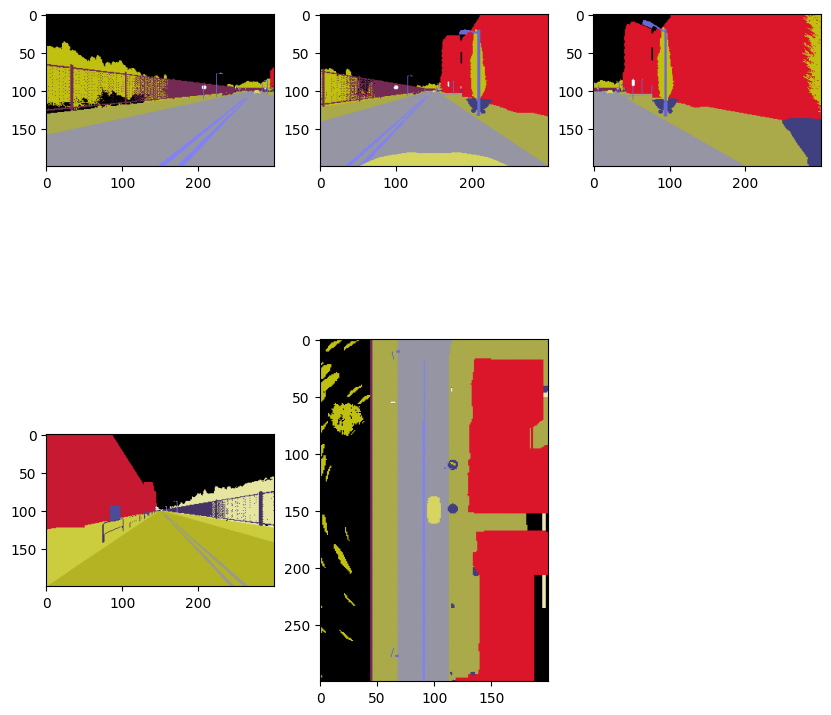

In [ ]:
plot_cameras(10)

In [ ]:
import os

def get_paths(val_size=2000):

  img_paths = []

  for i in range(len(os.listdir('/content/drive/MyDrive/Thesis/data2/top'))):
    path = f'{i}.npy'
    img_paths.append(path)

  return pd.DataFrame({'path':img_paths[:-val_size]}), pd.DataFrame({'path':img_paths[-val_size:]})

In [ ]:
img_paths_train, img_paths_val = get_paths()
img_paths_train

,path
0,0.npy
1,1.npy
2,2.npy
3,3.npy
4,4.npy
...,...
7995,7995.npy
7996,7996.npy
7997,7997.npy
7998,7998.npy


In [ ]:
img_paths_val

,path
0,8000.npy
1,8001.npy
2,8002.npy
3,8003.npy
4,8004.npy
...,...
1995,9995.npy
1996,9996.npy
1997,9997.npy
1998,9998.npy


In [ ]:
def img_to_categorical(img, needed_labels):

  cat = np.empty((img.shape[0], img.shape[1], len(needed_labels)))

  for channel, label in enumerate(needed_labels):
    cat[:, :, channel] = np.where(np.isin(img, label), 1, 0)

  return cat

def categorical_to_img(cat):

  img = np.argmax(cat, axis=-1)
  return img

needed_labels = [0, 1, 6, 7, 8, 10, 11]

In [ ]:
from tensorflow.keras.utils import Sequence

class DataGenerator2D(Sequence):
    """Generates data for Keras
    Sequence based data generator. Suitable for building data generator for training and prediction.
    """
    def __init__(self, img_paths, base_path, to_fit=True, batch_size=32, shuffle=True, needed_classes = []):

        self.img_paths = img_paths.copy()
        self.base_path = base_path
        self.to_fit = to_fit
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.needed_classes = needed_classes
        self.on_epoch_end()

    def __len__(self):
        """Denotes the number of batches per epoch
        :return: number of batches per epoch
        """
        return int(len(self.img_paths) // self.batch_size)

    def __getitem__(self, index):
        """Generate one batch of data
        :param index: index of the batch
        :return: X and y when fitting. X only when predicting
        """
        # Generate indexes of the batch
        current_indexes = list(range(index * self.batch_size, (index + 1) * self.batch_size))
        img_paths_temp = self.img_paths[current_indexes]

        # Generate data
        X = self._generate_X(img_paths_temp)

        if self.to_fit:
            y = self._generate_y(img_paths_temp)
            return X, y
        else:
            return X

    def on_epoch_end(self):
        """Updates indexes after each epoch
        """
        if self.shuffle == True:
            indices = np.arange(len(self.img_paths))
            np.random.shuffle(indices)
            self.img_paths = self.img_paths[indices]
            self.img_paths.reset_index(drop=True, inplace=True)


    def _generate_X(self, img_paths_temp):
        """Generates data containing batch_size images
        :param img_paths_temp: list of label ids to load
        :return: batch of images
        """
        # Initialization

        X = []

        # Generate data
        for idx, path in zip(img_paths_temp.index, img_paths_temp):
            # Store sample
            img = self._load_image(path)
            X.append(img)

        return np.array(X)

    def _generate_y(self, img_paths_temp):

        y = []

        for idx, path in zip(img_paths_temp.index, img_paths_temp):
            # Store sample
            img = self._load_image(path, front=False)
            y.append(img)
        return np.array(y)

    def _load_image(self, image_path, front=True):

        if front:
          img_dir =  '/front/'
        else:
          img_dir =  '/top/'

        img = np.load(self.base_path + img_dir + image_path)
        img = img[::2, ::2]                                          # Downsampling image by factor of 2

        if not front:
          img = img[3:(img.shape[0]//2)]
          img = np.rot90(img)
          img = img[2:-2]                                           # Crop Image to make dimensions divisible by 8
          img = img_to_categorical(img, self.needed_classes)

          return img

        img = img[2:-2, 3:-3]                                       # Crop Image to make dimensions divisible by 8
        img = img_to_categorical(img, self.needed_classes)

        return img

In [ ]:
train_generator = DataGenerator2D(img_paths_train['path'], '/content/drive/MyDrive/Thesis/data2', batch_size=32, shuffle=True, needed_classes=needed_labels)
val_generator = DataGenerator2D(img_paths_val['path'], '/content/drive/MyDrive/Thesis/data2', batch_size=1, shuffle=False, needed_classes=needed_labels)

In [ ]:
# Test the generator

X, y = train_generator.__getitem__(0)
print(X.shape, y.shape)

(32, 96, 144, 7) (32, 96, 72, 7)


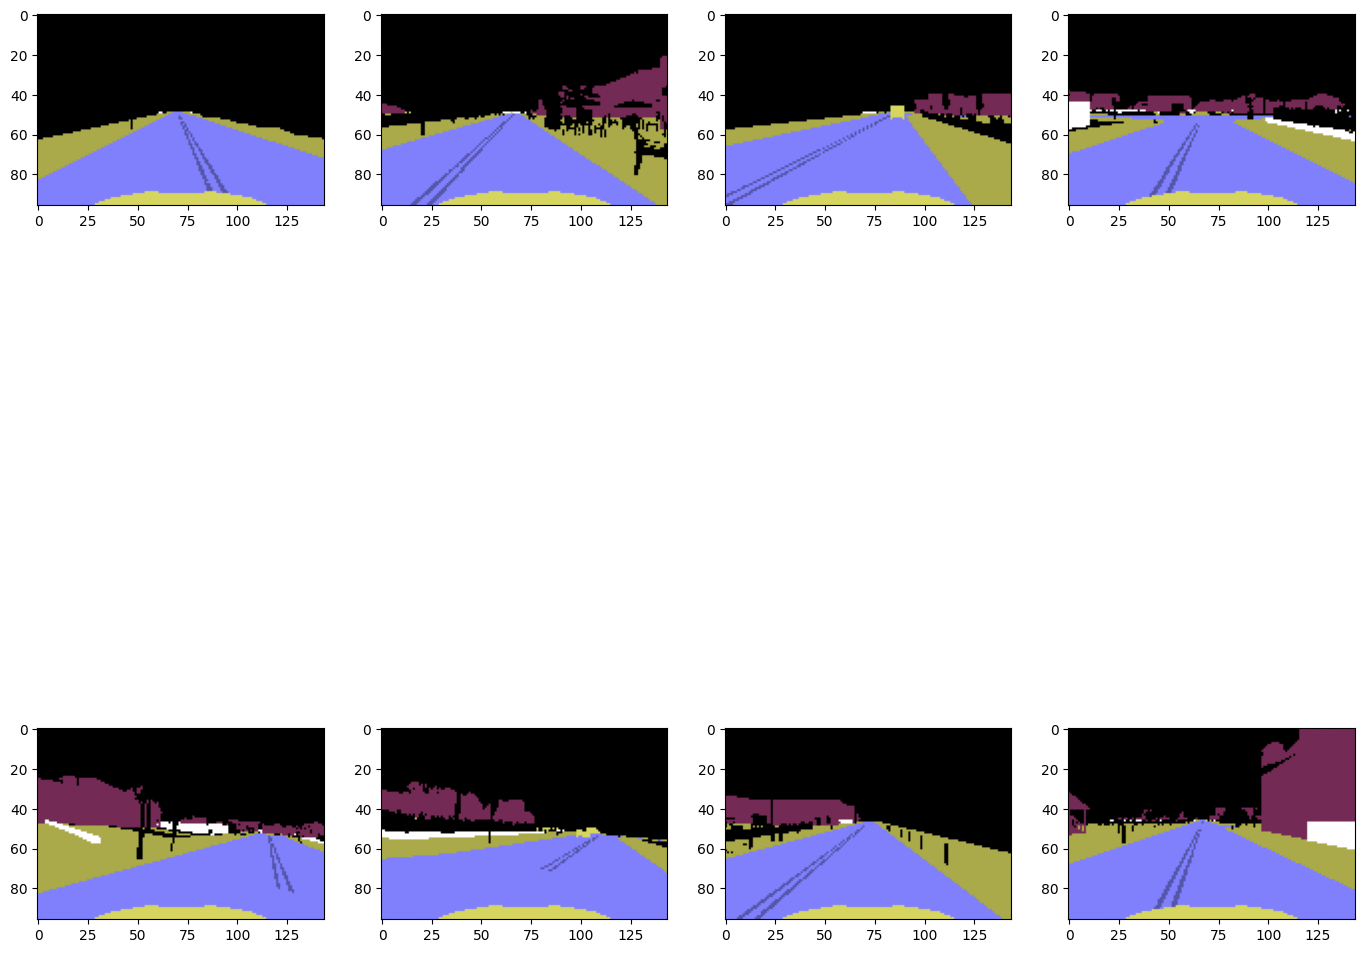

In [ ]:
fig=plt.figure(figsize=(17, 17))
columns = 4
rows = 2
for i in range(1, columns*rows + 1):
    img = X[i-1]
    fig.add_subplot(rows, columns, i)
    plt.imshow(categorical_to_img(img), cmap='gist_stern', vmin=0, vmax=len(needed_labels)-1)
plt.show()

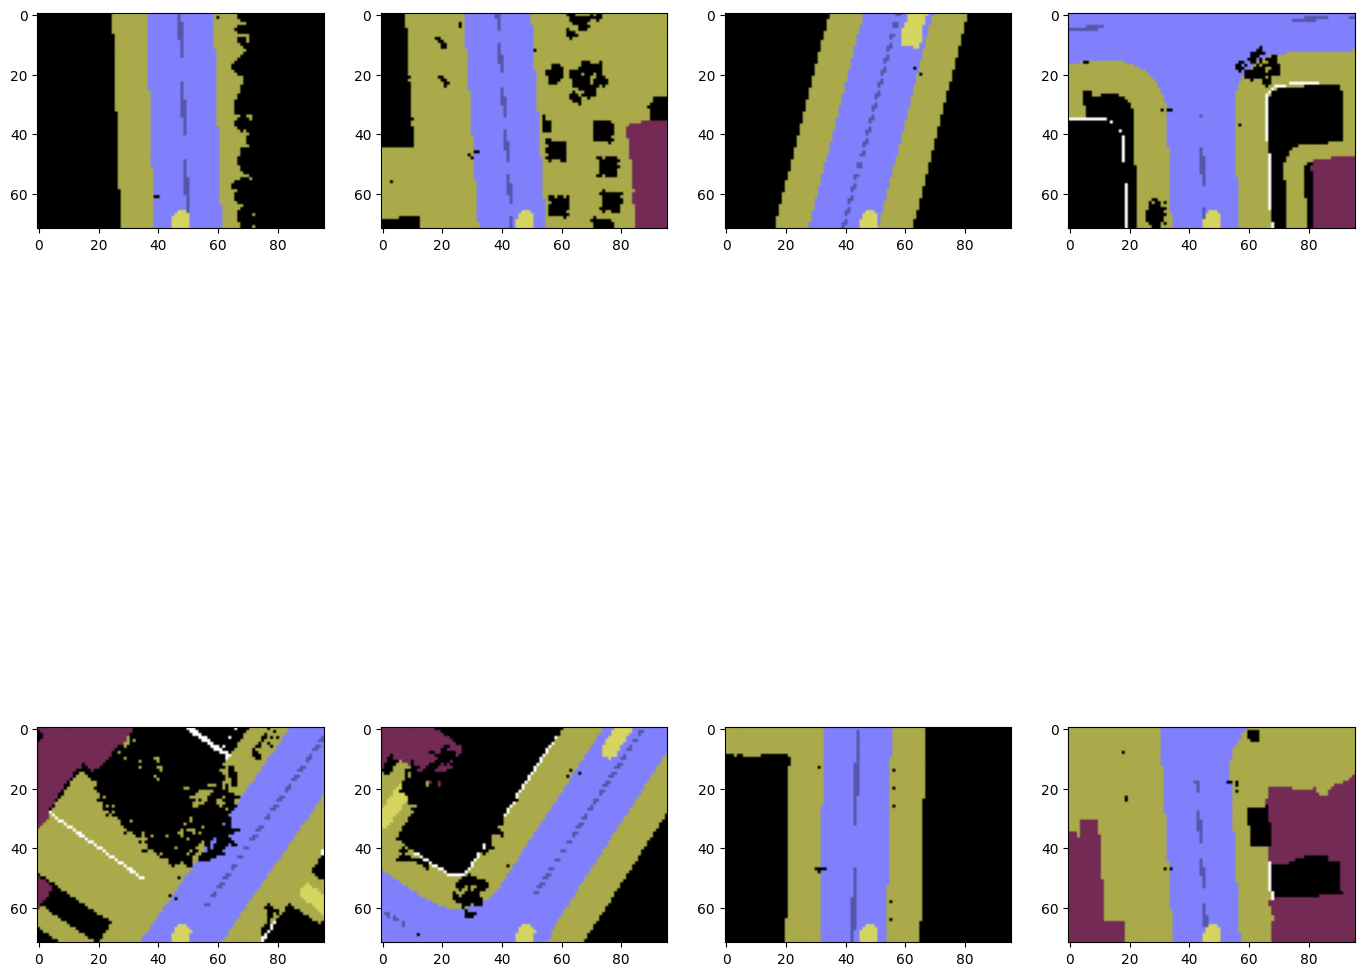

In [ ]:
fig=plt.figure(figsize=(17, 17))
columns = 4
rows = 2
for i in range(1, columns*rows + 1):
    img = y[i-1]
    fig.add_subplot(rows, columns, i)
    plt.imshow(np.rot90(categorical_to_img(img), 3), cmap='gist_stern', vmin=0, vmax=len(needed_labels)-1)
plt.show()

In [ ]:
import time
import keras.backend as K
from keras import Input, Model
from keras.layers import Convolution2D, LeakyReLU, BatchNormalization, UpSampling2D, Subtract, Concatenate, Softmax, Dropout, Activation,MaxPooling2D, Flatten, Dense, Lambda, Reshape, concatenate, ZeroPadding2D, Cropping2D
from keras.optimizers import Adam
from keras import Sequential

###Model (U-net Generator)

In [ ]:
def build_unet_generator(needed_labels):

  """
  Create U-Net Generator using the hyperparameter values defined
  below
  """

  kernel_size = [8, 6, 4, 6, 6, 8]
  strides = 2
  leakyrelu_alpha = 0.2
  upsampling_size = 2
  output_channels = len(needed_labels)
  input_shape = (96, 144, len(needed_labels))

  # Setting up the input
  input_layer = Input(shape=input_shape)

  # Encoder Network

  # 1st Convolutional block in the encoder network
  encoder1 = Convolution2D(filters=64, kernel_size=8,
  padding='same',
  strides=strides)(input_layer)
  encoder1 = LeakyReLU(alpha=leakyrelu_alpha)(encoder1)
  # 2nd Convolutional block in the encoder network
  encoder2 = Convolution2D(filters=128, kernel_size=6,
  padding='same',
  strides=strides)(encoder1)
  encoder2 = BatchNormalization()(encoder2)
  encoder2 = LeakyReLU(alpha=leakyrelu_alpha)(encoder2)
  # 3rd Convolutional block in the encoder network
  encoder3 = Convolution2D(filters=256, kernel_size=4,
  padding='same',
  strides=strides)(encoder2)
  encoder3 = BatchNormalization()(encoder3)
  encoder3 = LeakyReLU(alpha=leakyrelu_alpha)(encoder3)

  # 1st Upsampling Convolutional block in the decoder network
  decoder6 = UpSampling2D(size=upsampling_size)(encoder3)
  decoder6 = Convolution2D(filters=128, kernel_size=6,
  padding='same')(decoder6)
  decoder6 = BatchNormalization()(decoder6)
  decoder6 = concatenate([decoder6, encoder2])
  decoder6 = LeakyReLU(alpha=leakyrelu_alpha)(decoder6)
  # 2nd Upsampling Convolutional block in the decoder network
  decoder7 = UpSampling2D(size=upsampling_size)(decoder6)
  decoder7 = Convolution2D(filters=64, kernel_size=6,
  padding='same')(decoder7)
  decoder7 = BatchNormalization()(decoder7)
  decoder7 = concatenate([decoder7, encoder1])
  decoder7 = LeakyReLU(alpha=leakyrelu_alpha)(decoder7)


  # Last Convolutional layer
  decoder8 = UpSampling2D(size=(2, 1))(decoder7)
  decoder8 = Convolution2D(filters=output_channels,
  kernel_size=8, padding='same')(decoder8)
  decoder8 = Activation('softmax')(decoder8)

  model = Model(inputs=[input_layer], outputs=[decoder8])

  return model

In [ ]:
model = build_unet_generator(needed_labels)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1             │ (None, 96, 144, 7)     │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_6 (Conv2D)         │ (None, 48, 72, 64)     │         28,736 │ input_layer_1[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ leaky_re_lu_5 (LeakyReLU) │ (None, 48, 72, 64)     │              0 │ conv2d_6[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_7 (Conv2D)         │ (None, 24, 36, 128)    │        295,040 │ leaky_re_lu_5[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_4     │ (None, 24, 36, 128)    │            512 │ conv2d_7[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ leaky_re_lu_6 (LeakyReLU) │ (None, 24, 36, 128)    │              0 │ batch_normalization_4… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_8 (Conv2D)         │ (None, 12, 18, 256)    │        524,544 │ leaky_re_lu_6[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_5     │ (None, 12, 18, 256)    │          1,024 │ conv2d_8[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ leaky_re_lu_7 (LeakyReLU) │ (None, 12, 18, 256)    │              0 │ batch_normalization_5… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ up_sampling2d_3           │ (None, 24, 36, 256)    │              0 │ leaky_re_lu_7[0][0]    │
│ (UpSampling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_9 (Conv2D)         │ (None, 24, 36, 128)    │      1,179,776 │ up_sampling2d_3[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_6     │ (None, 24, 36, 128)    │            512 │ conv2d_9[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate_2             │ (None, 24, 36, 256)    │              0 │ batch_normalization_6… │
│ (Concatenate)             │                        │                │ leaky_re_lu_6[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ leaky_re_lu_8 (LeakyReLU) │ (None, 24, 36, 256)    │              0 │ concatenate_2[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ up_sampling2d_4           │ (None, 48, 72, 256)    │              0 │ leaky_re_lu_8[0][0]    │
│ (UpSampling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_10 (Conv2D)        │ (None, 48, 72, 64)     │        589,888 │ up_sampling2d_4[0][0]  │
├──────────────────────

 Total params: 2,677,639 (10.21 MB)

 Trainable params: 2,676,487 (10.21 MB)

 Non-trainable params: 1,152 (4.50 KB)

In [ ]:
# Checking if the model can run at real time on current GPU at specified fps

from time import time
fps = 30

x = np.random.random((96, 144, len(needed_labels)))
start = time()

for i in range(fps):
  out = model.predict(np.array([x]))

print(time() - start)

/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_22']
Received: inputs=Tensor(shape=(1, 96, 144, 7))
  warnings.warn(msg)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 848ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━

In [ ]:
import os
from keras.optimizers import Nadam
from keras.callbacks import ModelCheckpoint, TensorBoard, EarlyStopping, LearningRateScheduler
from tensorflow.keras.optimizers.schedules import ExponentialDecay
from time import time

# Define the directories for logs and models
log_dir = "/content/drive/MyDrive/Thesis/self_driving(f_Unet1)/logs/BirdsEye{}".format(time())
model_dir = "/content/drive/MyDrive/Thesis/self_driving(f_Unet1)/models"

# Ensure the directories exist
os.makedirs(log_dir, exist_ok=True)
os.makedirs(model_dir, exist_ok=True)

# Define the learning rate decay schedule using ExponentialDecay
lr_schedule = ExponentialDecay(
    initial_learning_rate=1e-4,  # Starting learning rate
    decay_steps=100000,          # Number of steps before applying decay
    decay_rate=0.96,             # Decay rate (e.g., 0.96 reduces the LR by 4% every decay step)
    staircase=True               # Whether to apply decay in discrete steps or continuously
)

# Wrap the ExponentialDecay schedule in a function to return a Python float
def lr_schedule_function(epoch):
    return float(lr_schedule(epoch))  # Convert NumPy float to Python float

# Set up the Nadam optimizer with the learning rate decay
optimizer = Nadam(learning_rate=lr_schedule, beta_1=0.9, beta_2=0.999, epsilon=1e-08)

# Callbacks
tensorboard = TensorBoard(log_dir=log_dir)
early_stopping = EarlyStopping(monitor='val_loss', patience=30)

# Model checkpoint setup (to save the model during training)
filepath = model_dir + "/BirdsEye_cat_simple-2-saved-model-{epoch:02d}-{val_loss:.5f}.keras"  # Change to .keras extension
checkpoint = ModelCheckpoint(filepath, monitor='val_loss', verbose=1, save_best_only=False)

# Learning rate scheduler callback (for manual decay)
lr_scheduler = LearningRateScheduler(lr_schedule_function)

# Combine all callbacks into a list
callbacks_list = [checkpoint, tensorboard, early_stopping, lr_scheduler]

# Now you can use this optimizer and callbacks list in your model.fit() call


In [ ]:
import tensorflow as tf

def dice_coef(y_true, y_pred, smooth=1):
    # Flatten the tensors using tf.reshape
    y_true_f = tf.reshape(y_true, [-1])  # Flatten the tensor to 1D
    y_pred_f = tf.reshape(y_pred, [-1])  # Flatten the tensor to 1D

    # Calculate the intersection
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth)

# Dice coefficient for multi-label classification
def dice_coef_multilabel(y_true, y_pred, numLabels=len(needed_labels)):
    dice = 0
    for index in range(0, numLabels):
        dice -= dice_coef(y_true[:, :, :, index], y_pred[:, :, :, index])
    return numLabels + dice

# SSIM (Structural Similarity Index) loss
def ssim_loss(y_true, y_pred):
    return 1 - tf.reduce_mean(tf.image.ssim(y_true, y_pred, 1.0))

# Custom loss function combining Dice loss and SSIM loss
def custom_loss(y_true, y_pred):
    return dice_coef_multilabel(y_true, y_pred) + 5 * ssim_loss(y_true, y_pred)


In [ ]:
model.compile(optimizer='adam', loss=custom_loss, metrics=['categorical_accuracy'])

In [ ]:
NUM_EPOCHS = 50

history = model.fit(train_generator, epochs=NUM_EPOCHS,
                    shuffle=True, callbacks=callbacks_list,
                    validation_data=val_generator)

# Save the training history
import pickle

history_save_path = '/content/drive/MyDrive/Thesis/self_driving(f_Unet1)/history/history.pkl'

with open(history_save_path, 'wb') as f:
    pickle.dump(history.history, f)

print(f"History saved at {history_save_path}")


Epoch 1/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step - categorical_accuracy: 0.7018 - loss: 4.8743
Epoch 1: saving model to /content/drive/MyDrive/Thesis/self_driving(f_Unet1)/models/BirdsEye_cat_simple-2-saved-model-01-4.68655.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 87s 315ms/step - categorical_accuracy: 0.7018 - loss: 4.8743 - val_categorical_accuracy: 0.7170 - val_loss: 4.6865 - learning_rate: 1.0000e-04
Epoch 2/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 242ms/step - categorical_accuracy: 0.7098 - loss: 4.8173
Epoch 2: saving model to /content/drive/MyDrive/Thesis/self_driving(f_Unet1)/models/BirdsEye_cat_simple-2-saved-model-02-4.70615.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 79s 307ms/step - categorical_accuracy: 0.7098 - loss: 4.8172 - val_categorical_accuracy: 0.7226 - val_loss: 4.7062 - learning_rate: 1.0000e-04
Epoch 3/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step - categorical_accuracy: 0.7121 - loss: 4.7634
Epoch 3: saving model to /content/drive/MyDrive/Thesis/self_driving(f_Unet1)/models/Bi

###Testing (U-net Generator)

In [ ]:
from keras.models import load_model

model = load_model('/content/drive/MyDrive/Thesis/self_driving(f_Unet1)/models/BirdsEye_cat_simple-2-saved-model-50-3.95865.keras', compile=False)


In [ ]:

X, y = val_generator.__getitem__(0)
print(X.shape, y.shape)

(1, 96, 144, 7) (1, 96, 72, 7)


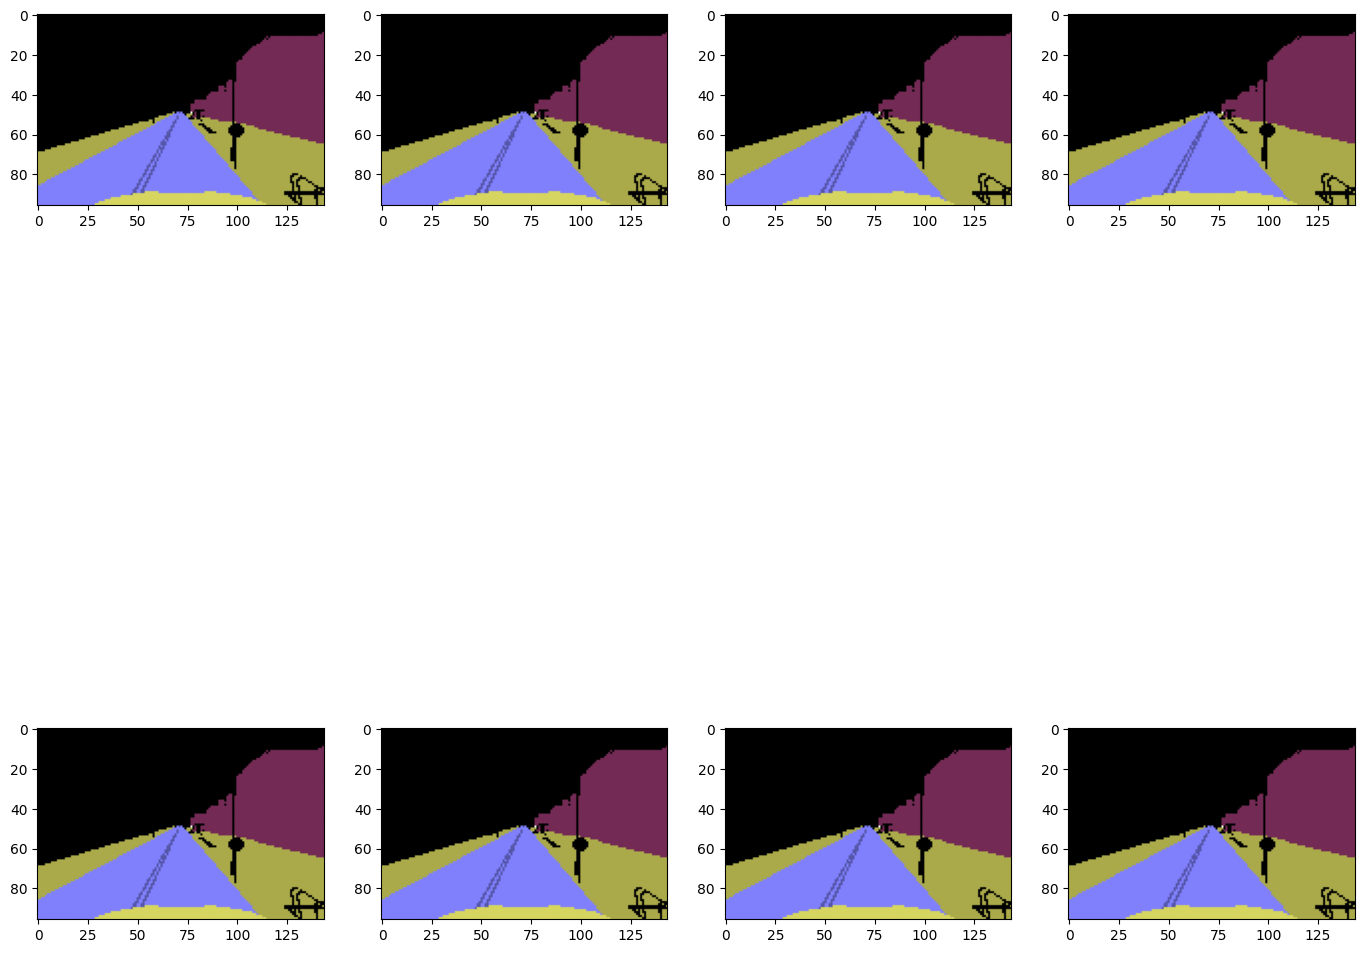

In [ ]:
fig=plt.figure(figsize=(17, 17))
columns = 4
rows = 2

for i in range(1, columns*rows + 1):
    img = X[0]
    fig.add_subplot(rows, columns, i)
    plt.imshow(categorical_to_img(img), cmap='gist_stern', vmin=0, vmax=len(needed_labels) - 1)
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 852ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


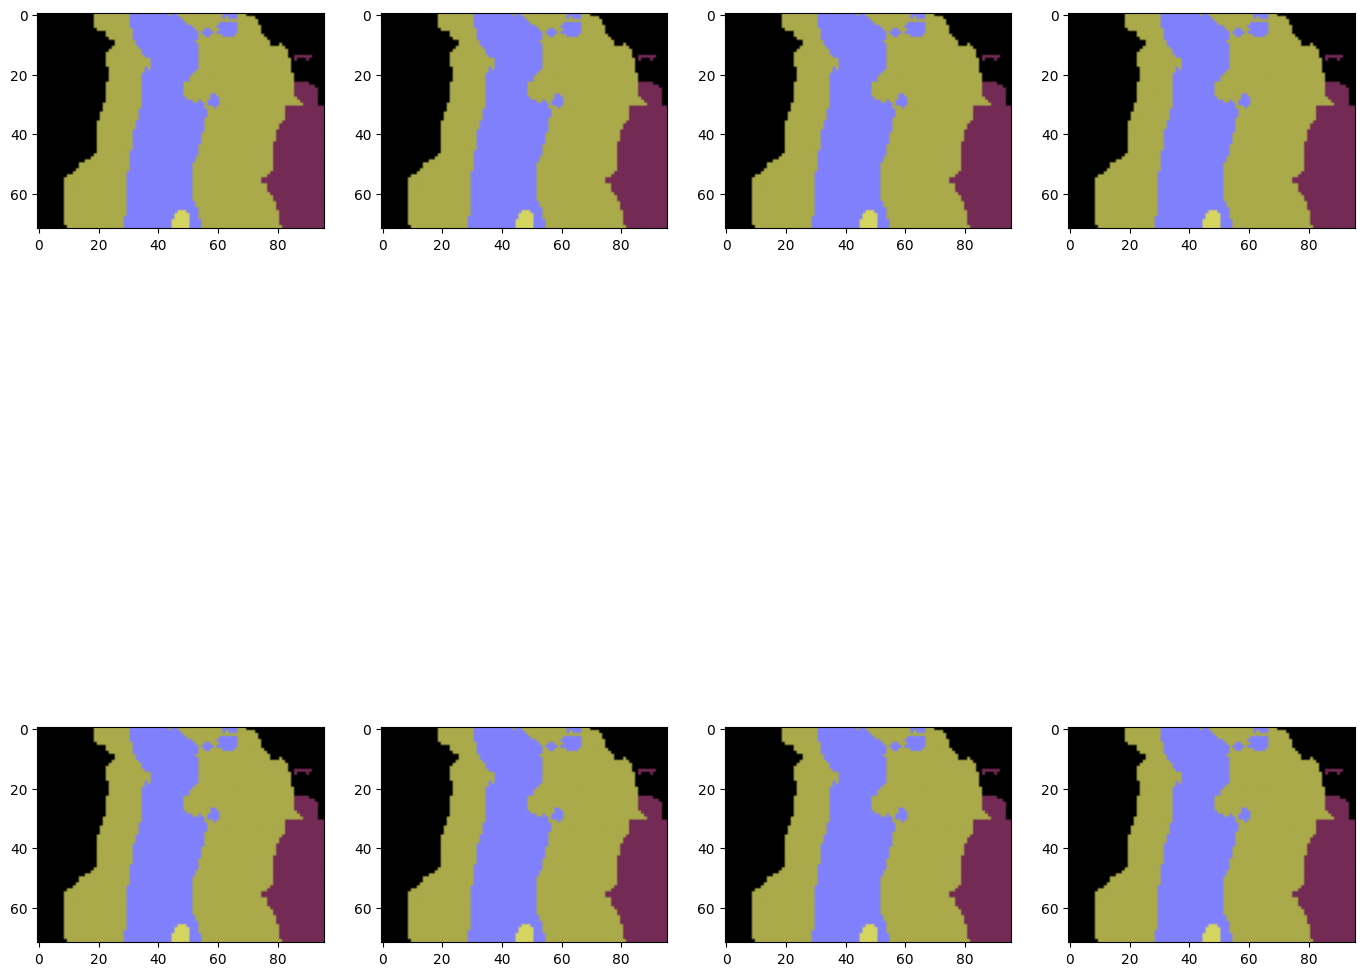

In [ ]:
fig=plt.figure(figsize=(17, 17))
columns = 4
rows = 2
for i in range(1, columns*rows + 1):
    img = X[0]
    pred = model.predict(np.array([img]))
    fig.add_subplot(rows, columns, i)
    plt.imshow(np.rot90(categorical_to_img(pred[0]), 3), cmap='gist_stern', vmin=0, vmax=len(needed_labels)-1)
plt.show()

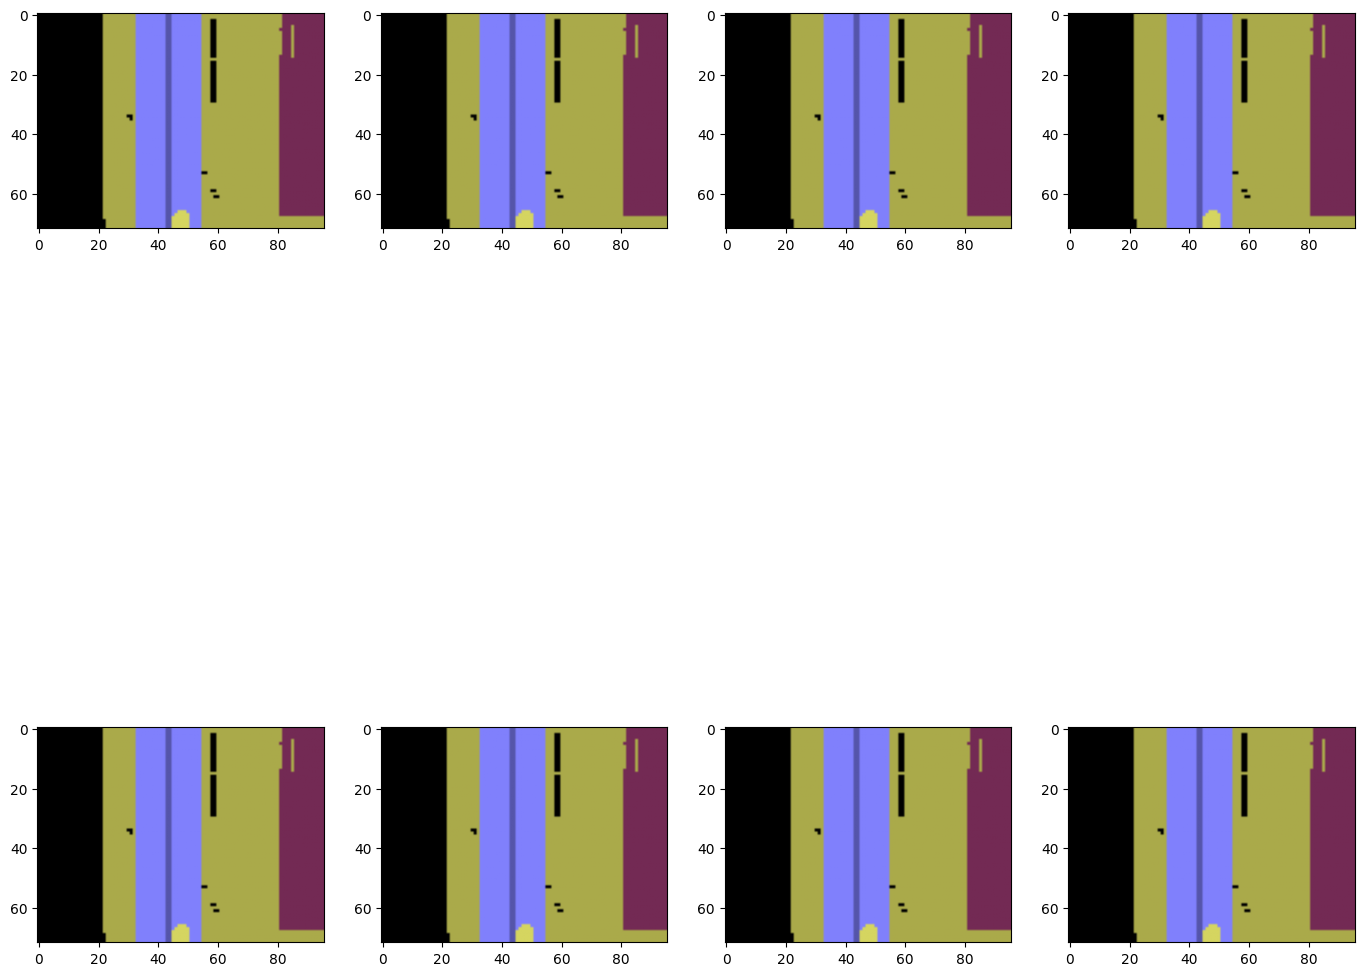

In [ ]:
fig=plt.figure(figsize=(17, 17))
columns = 4
rows = 2
for i in range(1, columns*rows + 1):
    img = y[0]
    fig.add_subplot(rows, columns, i)
    plt.imshow(np.rot90(categorical_to_img(img), 3), cmap='gist_stern', vmin=0, vmax=len(needed_labels)-1)

###Validations


In [ ]:
import pickle

# Load the history from the .pkl file
with open('/content/drive/MyDrive/Thesis/self_driving(f_Unet1)/history/history.pkl', 'rb') as f:
    history = pickle.load(f)

# Check the available keys in the history
print(history.keys())


dict_keys(['categorical_accuracy', 'loss', 'val_categorical_accuracy', 'val_loss', 'learning_rate'])


In [ ]:
# Required Imports
import matplotlib.pyplot as plt
import numpy as np
from keras.models import load_model
import pickle

# Path to Saved Model
model_path = "/content/drive/MyDrive/Thesis/self_driving(f_Unet1)/models/BirdsEye_cat_simple-2-saved-model-50-3.95865.keras"

# Load the Model with Custom Loss Functions
model = load_model(
    model_path,
    custom_objects={
        'custom_loss': custom_loss,
        'dice_coef_multilabel': dice_coef_multilabel
    }
)

# Load Training History
history_path = '/content/drive/MyDrive/Thesis/self_driving(f_Unet1)/history/history.pkl'
with open(history_path, 'rb') as f:
    history = pickle.load(f)

# Load enough samples from the validation generator
num_samples = 5  # Desired number of samples
X, y = val_generator.__getitem__(0)
for i in range(1, num_samples):
    X_temp, y_temp = val_generator.__getitem__(i)
    X = np.concatenate([X, X_temp])
    y = np.concatenate([y, y_temp])

# 1. Loss Curve
def plot_loss_curve(history):
    plt.figure(figsize=(8, 6))
    plt.plot(history['loss'], label='Training Loss', color='blue')
    plt.plot(history['val_loss'], label='Validation Loss', color='orange')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

# 2. Accuracy Curve (Categorical Accuracy)
def plot_accuracy_curve(history):
    plt.figure(figsize=(8, 6))
    plt.plot(history['categorical_accuracy'], label='Training Accuracy', color='blue')
    plt.plot(history['val_categorical_accuracy'], label='Validation Accuracy', color='orange')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.legend()
    plt.grid(True)
    plt.show()

# 3. Sample Segmentation Results
def plot_sample_segmentation_results(model, X, y, num_samples=5):
    fig, axes = plt.subplots(3, num_samples, figsize=(20, 10))
    for i in range(num_samples):
        input_image = X[i]
        true_mask = np.argmax(y[i], axis=-1)
        predicted_mask = np.argmax(model.predict(np.array([input_image]))[0], axis=-1)

        # Convert input image to grayscale for display
        input_image_gray = np.mean(input_image, axis=-1)

        axes[0, i].imshow(categorical_to_img(input_image), cmap='gist_stern', vmin=0, vmax=len(needed_labels) - 1)
        axes[0, i].set_title(f'Input Image {i+1}')
        axes[0, i].axis('off')

        axes[1, i].imshow(true_mask, cmap='gist_stern')
        axes[1, i].set_title(f'Ground Truth {i+1}')
        axes[1, i].axis('off')

        axes[2, i].imshow(predicted_mask, cmap='gist_stern')
        axes[2, i].set_title(f'Prediction {i+1}')
        axes[2, i].axis('off')

    plt.tight_layout()
    plt.show()

# 4. Error Visualization
def plot_error_visualization(model, X, y, sample_index=0):
    input_image = X[sample_index]
    true_mask = np.argmax(y[sample_index], axis=-1)
    predicted_mask = np.argmax(model.predict(np.array([input_image]))[0], axis=-1)
    error_map = np.abs(true_mask - predicted_mask)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    input_image_gray = np.mean(input_image, axis=-1)
    axes[0].imshow(categorical_to_img(input_image), cmap='gist_stern', vmin=0, vmax=len(needed_labels) - 1)
    axes[0].set_title('Input Image')
    axes[0].axis('off')

    axes[1].imshow(true_mask, cmap='gist_stern')
    axes[1].set_title('Ground Truth Mask')
    axes[1].axis('off')

    axes[2].imshow(error_map, cmap='hot')
    axes[2].set_title('Error Map')
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

# 5. Learning Rate Schedule
def plot_learning_rate_schedule(history):
    plt.figure(figsize=(8, 6))
    plt.plot(history['learning_rate'], label='Learning Rate', color='green')
    plt.xlabel('Epochs')
    plt.ylabel('Learning Rate')
    plt.title('Learning Rate Schedule')
    plt.grid(True)
    plt.legend()
    plt.show()





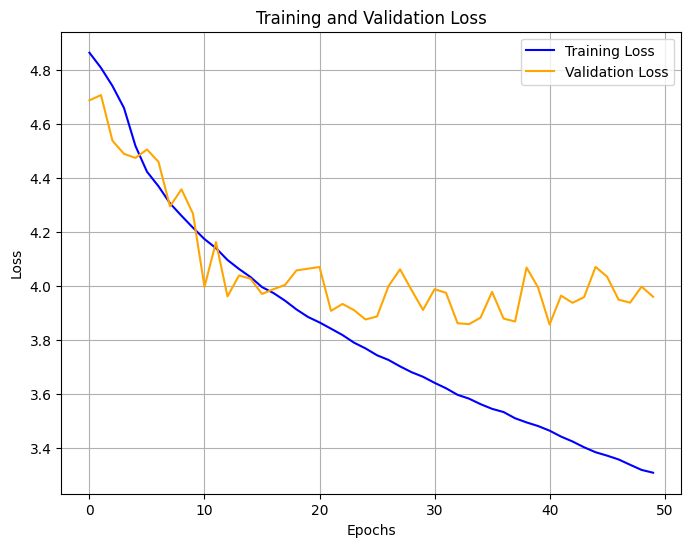

In [ ]:
plot_loss_curve(history)

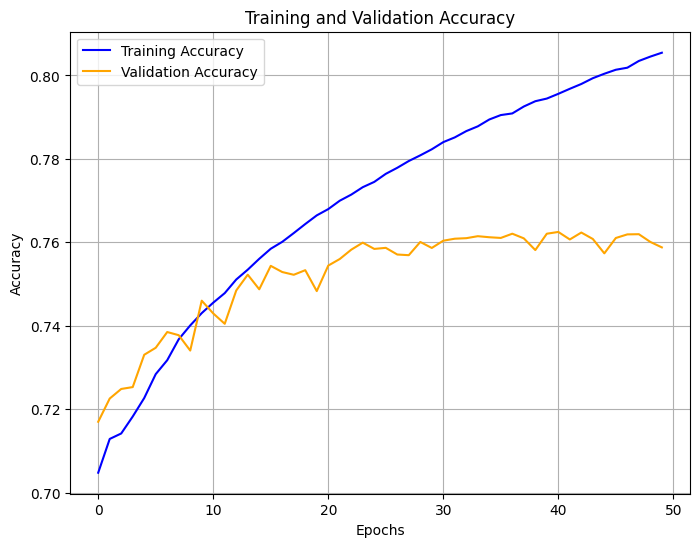

In [ ]:
plot_accuracy_curve(history)

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


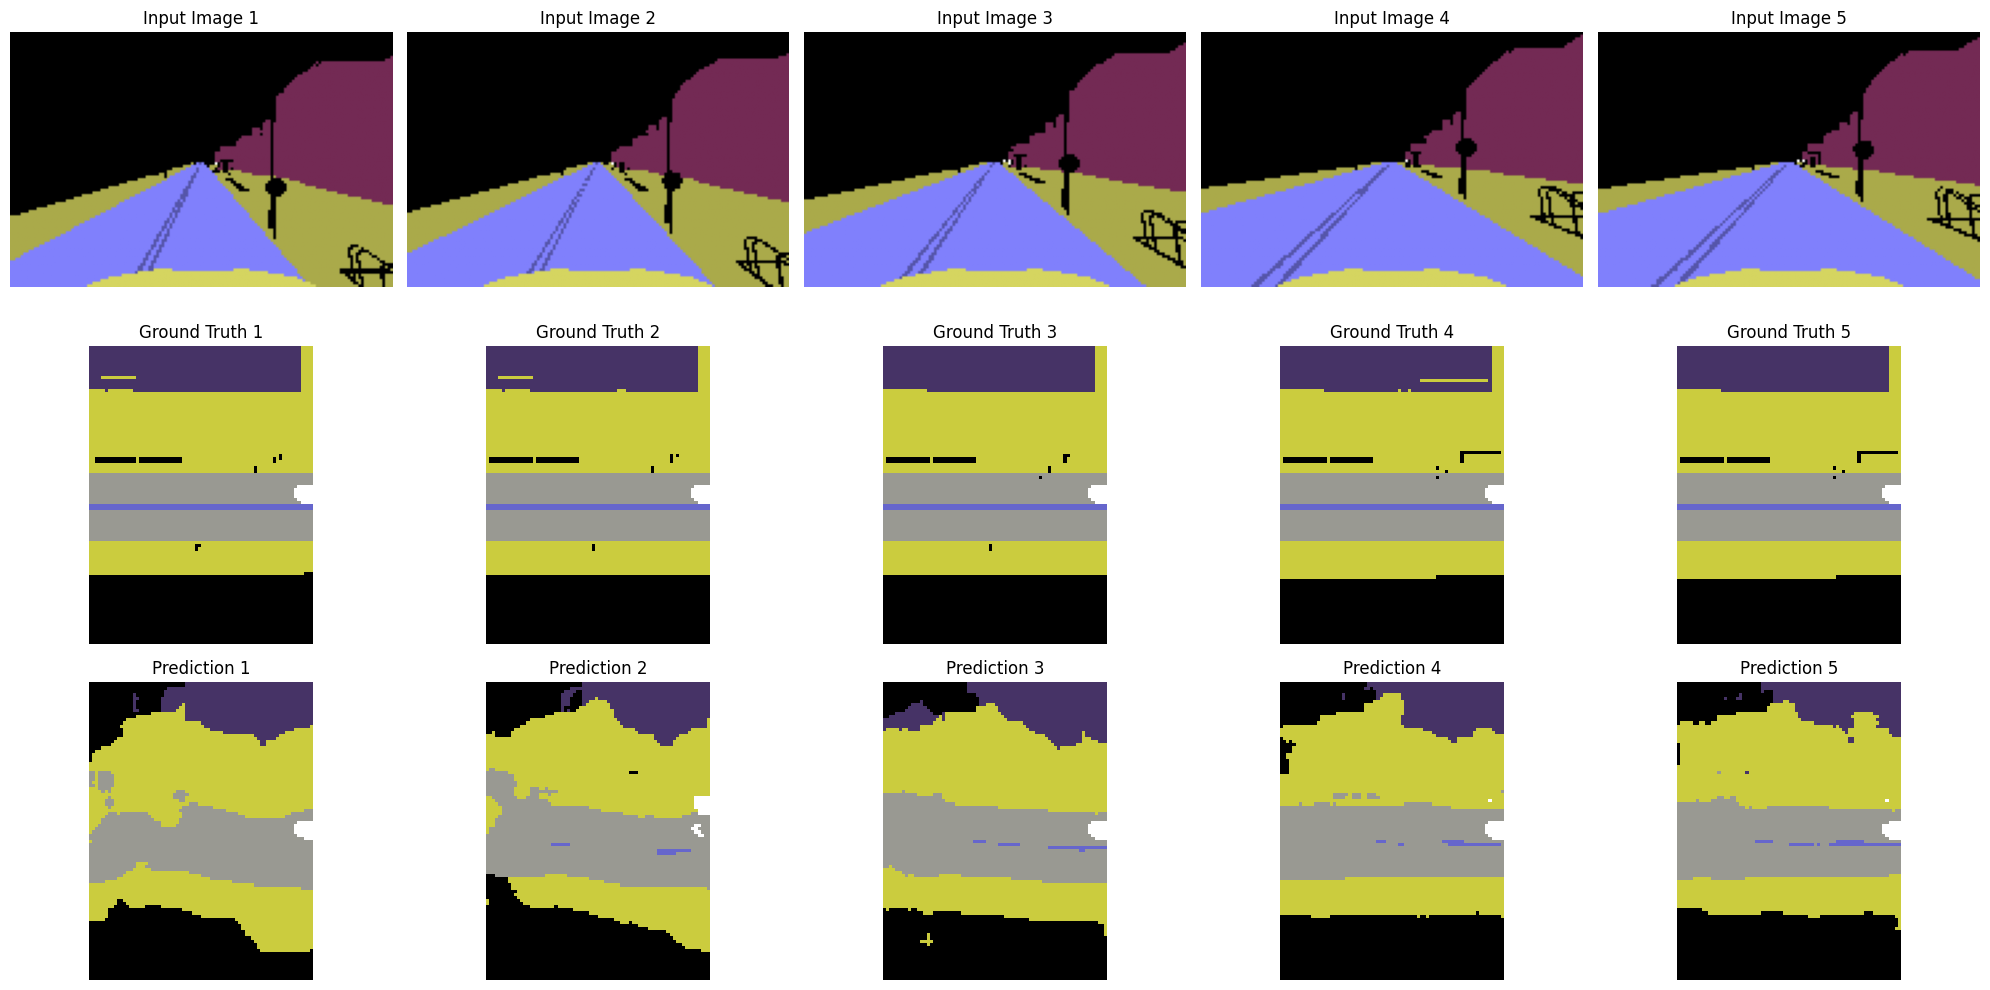

In [ ]:
plot_sample_segmentation_results(model, X, y, num_samples=num_samples)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


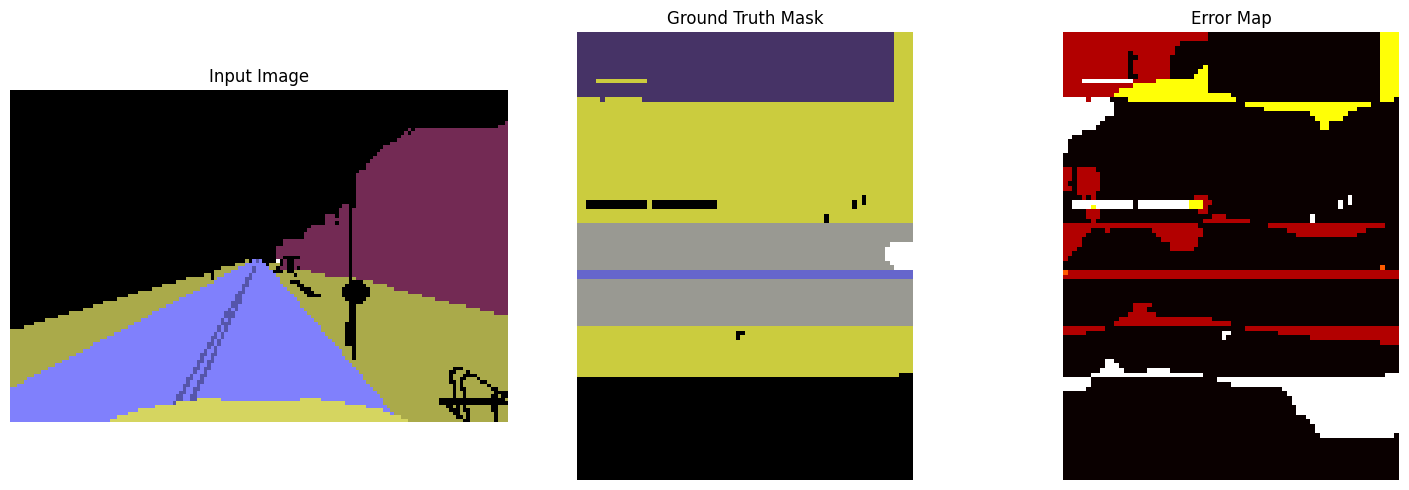

In [ ]:
plot_error_visualization(model, X, y, sample_index=0)


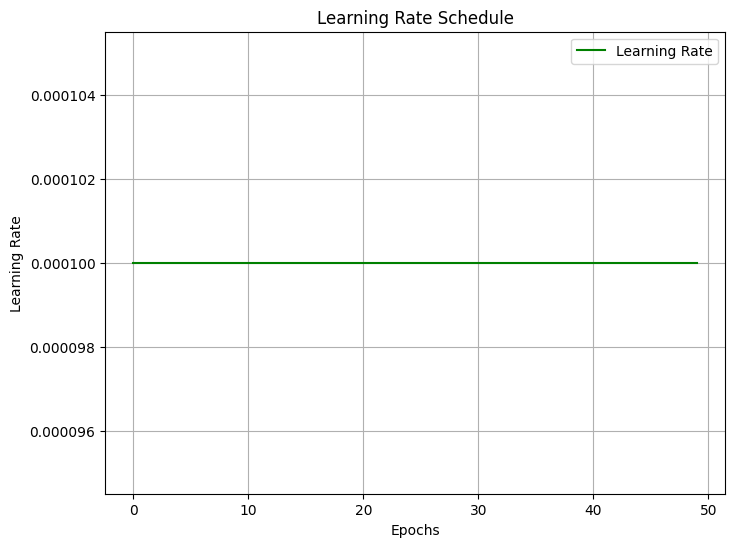

In [ ]:
plot_learning_rate_schedule(history)


In [ ]:
# Calculate Percentage Improvements
training_loss_reduction = ((history['loss'][0] - history['loss'][-1]) / history['loss'][0]) * 100
validation_loss_reduction = ((history['val_loss'][0] - history['val_loss'][-1]) / history['val_loss'][0]) * 100
training_accuracy_improvement = ((history['categorical_accuracy'][-1] - history['categorical_accuracy'][0]) / history['categorical_accuracy'][0]) * 100
validation_accuracy_improvement = ((history['val_categorical_accuracy'][-1] - history['val_categorical_accuracy'][0]) / history['val_categorical_accuracy'][0]) * 100

# Print Improvements
print(f"Training Loss Reduction: {training_loss_reduction:.2f}%")
print(f"Validation Loss Reduction: {validation_loss_reduction:.2f}%")
print(f"Training Accuracy Improvement: {training_accuracy_improvement:.2f}%")
print(f"Validation Accuracy Improvement: {validation_accuracy_improvement:.2f}%")

Training Loss Reduction: 32.00%
Validation Loss Reduction: 15.53%
Training Accuracy Improvement: 14.28%
Validation Accuracy Improvement: 5.83%


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step


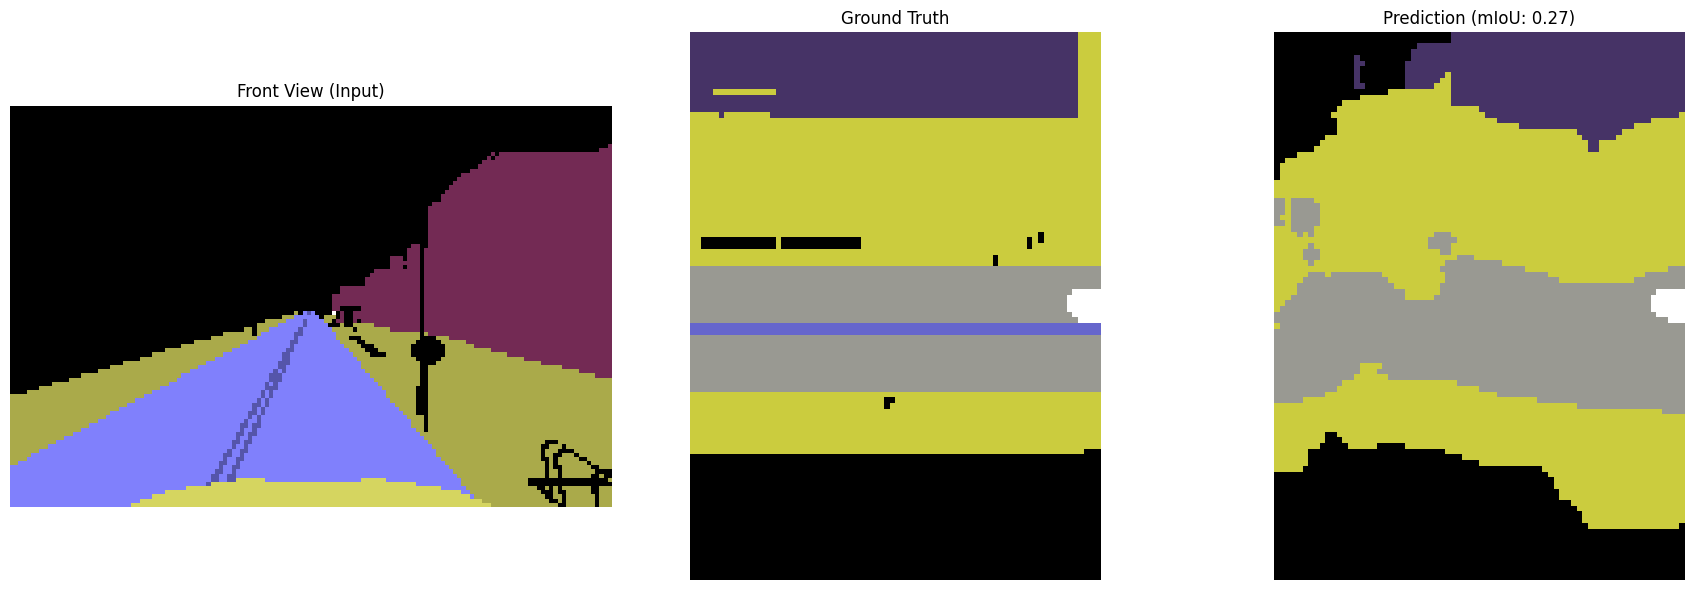

Mean IoU (mIoU): 0.27
IoU per class:
  None: 0.61
  Buildings: 0.54
  Fences: 0.00
  Other: 0.70
  Pedestrians: 0.67
  Poles: 0.97
  RoadLines: 0.00
  Roads: 0.00
  Sidewalks: 0.00
  Vegetation: 0.00
  Vehicles: 0.00
  Walls: 0.00
  TrafficSigns: 0.00


In [ ]:


import matplotlib.pyplot as plt
import numpy as np

# Define the class labels for better clarity in reporting
LABELS = {
    0: 'None',
    1: 'Buildings',
    2: 'Fences',
    3: 'Other',
    4: 'Pedestrians',
    5: 'Poles',
    6: 'RoadLines',
    7: 'Roads',
    8: 'Sidewalks',
    9: 'Vegetation',
    10: 'Vehicles',
    11: 'Walls',
    12: 'TrafficSigns',
}

def compute_miou(prediction, ground_truth, num_classes):
    """
    Computes Mean Intersection over Union (mIoU) for a single prediction and ground truth pair.
    :param prediction: Predicted mask.
    :param ground_truth: Ground truth mask.
    :param num_classes: Number of classes.
    :return: mIoU and IoU per class.
    """
    iou_per_class = np.zeros(num_classes)
    for c in range(num_classes):
        intersection = np.sum((prediction == c) & (ground_truth == c))
        union = np.sum((prediction == c) | (ground_truth == c))
        if union > 0:
            iou_per_class[c] = intersection / union
    miou = np.nanmean(iou_per_class)
    return miou, iou_per_class

def plot_final_comparison_with_miou(model, generator, sample_index=0, num_classes=len(LABELS)):
    """
    Visualizes the input image, ground truth, and model prediction for a single sample,
    and calculates mIoU.
    :param model: Trained model for prediction.
    :param generator: Data generator providing input and ground truth.
    :param sample_index: Index of the batch in the generator to visualize.
    :param num_classes: Number of classes for mIoU calculation.
    """
    # Load a batch of data
    X, y = generator.__getitem__(0)  # Get a batch from the generator
    input_image = X[0]  # Select the first image in the batch
    ground_truth = np.argmax(y[0], axis=-1)  # Convert one-hot encoded ground truth to class indices

    # Generate the model prediction
    predicted_mask = np.argmax(model.predict(np.array([input_image]))[0], axis=-1)

    # Compute mIoU
    miou, iou_per_class = compute_miou(predicted_mask, ground_truth, num_classes)

    # Create a figure to display the results
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # Convert input image to grayscale for better visualization
    input_image_gray = np.mean(input_image, axis=-1)

    # Input image
    axes[0].imshow(categorical_to_img(input_image), cmap='gist_stern', vmin=0, vmax=len(needed_labels) - 1)
    axes[0].set_title("Front View (Input)")
    axes[0].axis("off")

    # Ground truth
    axes[1].imshow(ground_truth, cmap="gist_stern")
    axes[1].set_title("Ground Truth")
    axes[1].axis("off")

    # Predicted result
    axes[2].imshow(predicted_mask, cmap="gist_stern")
    axes[2].set_title(f"Prediction (mIoU: {miou:.2f})")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

    # Print detailed IoU per class with labels
    print(f"Mean IoU (mIoU): {miou:.2f}")
    print("IoU per class:")
    for c, iou in enumerate(iou_per_class):
        class_name = LABELS.get(c, f"Class {c}")
        print(f"  {class_name}: {iou:.2f}")

# Example Usage
# Assuming `model` is your trained model and `val_generator` is the validation data generator
plot_final_comparison_with_miou(model, val_generator, sample_index=0, num_classes=len(LABELS))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


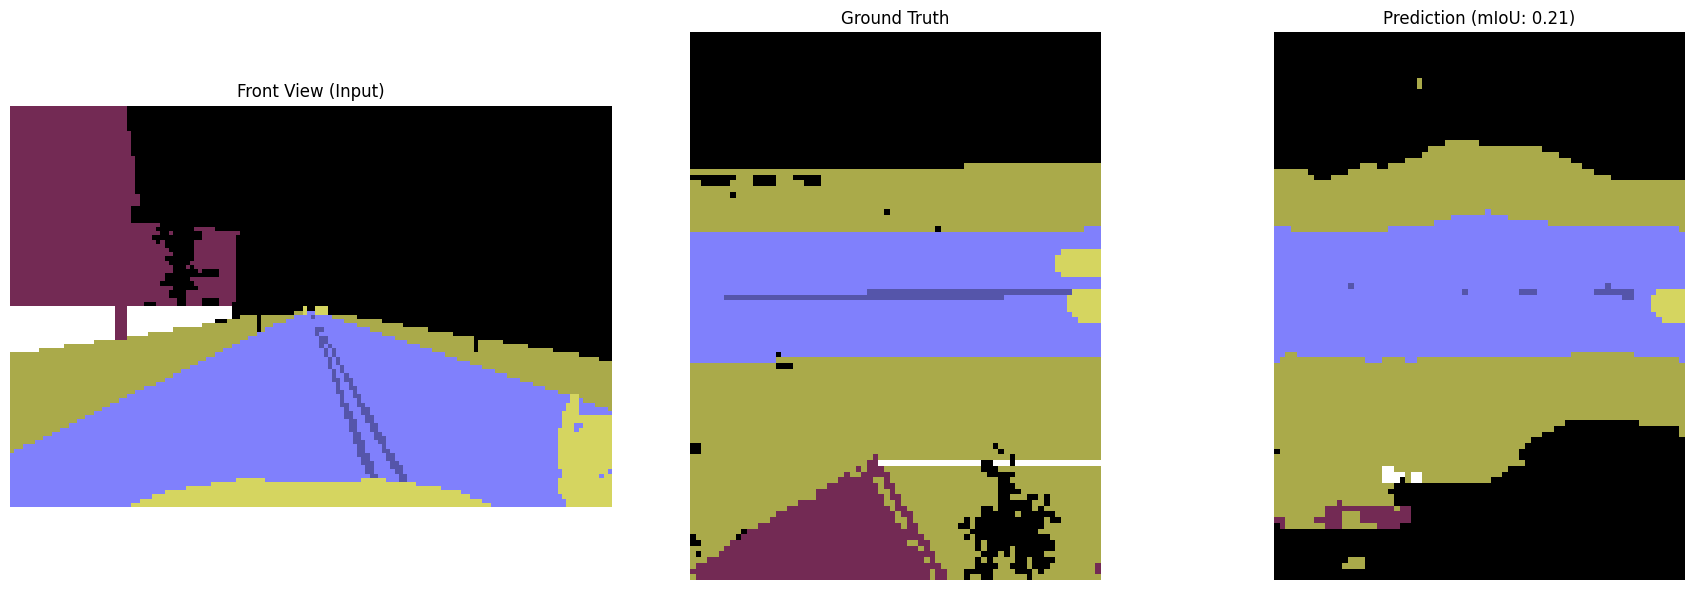

Batch 619:
Mean IoU (mIoU): 0.21
IoU per class:
  None: 0.57
  Buildings: 0.05
  Fences: 0.12
  Other: 0.86
  Pedestrians: 0.64
  Poles: 0.46
  RoadLines: 0.00
  Roads: 0.00
  Sidewalks: 0.00
  Vegetation: 0.00
  Vehicles: 0.00
  Walls: 0.00
  TrafficSigns: 0.00


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


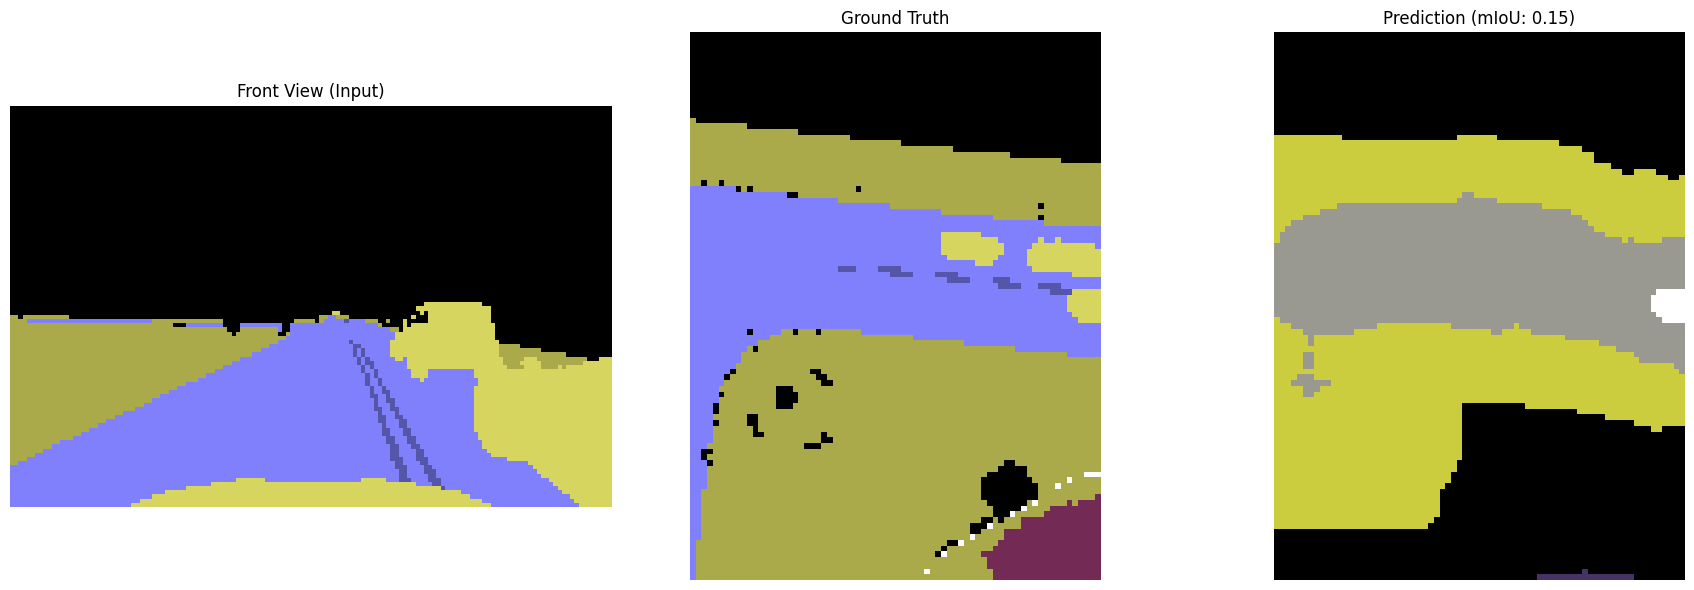

Batch 1573:
Mean IoU (mIoU): 0.15
IoU per class:
  None: 0.48
  Buildings: 0.05
  Fences: 0.00
  Other: 0.71
  Pedestrians: 0.54
  Poles: 0.21
  RoadLines: 0.00
  Roads: 0.00
  Sidewalks: 0.00
  Vegetation: 0.00
  Vehicles: 0.00
  Walls: 0.00
  TrafficSigns: 0.00


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


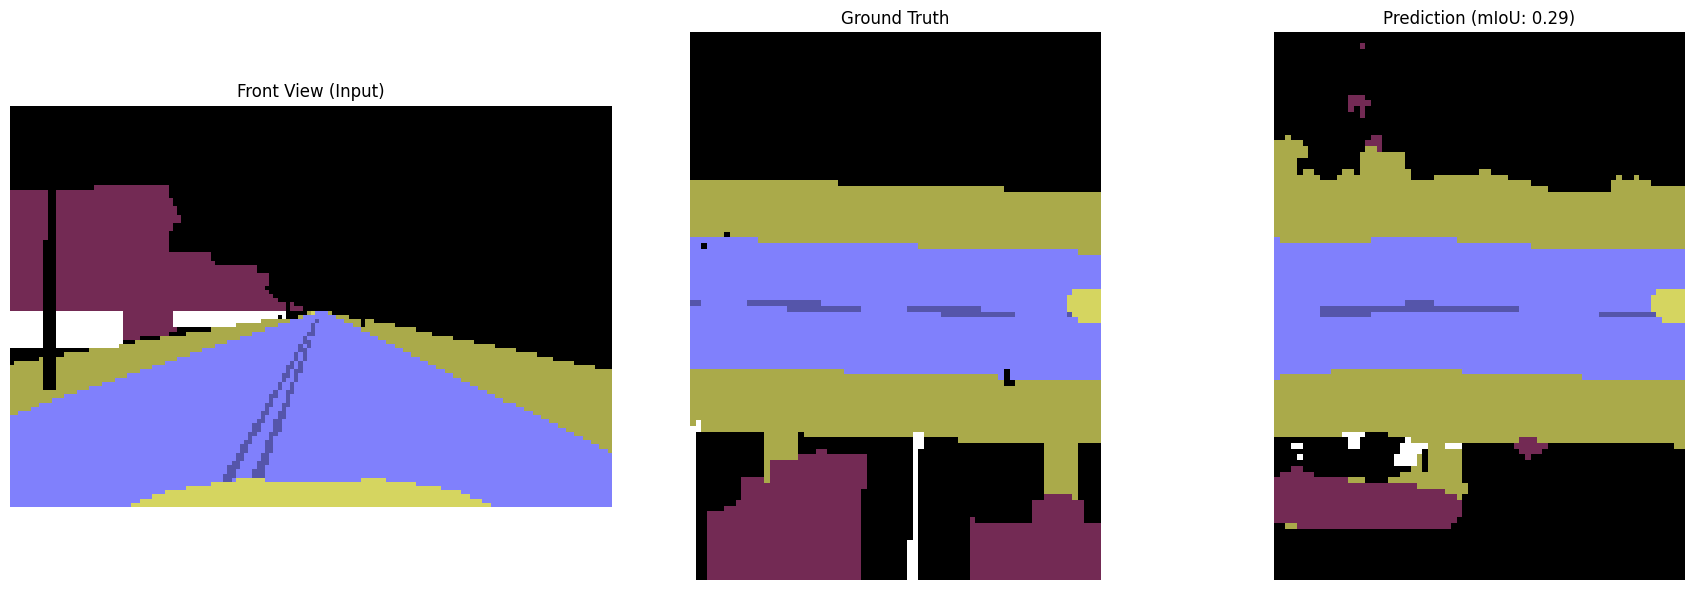

Batch 768:
Mean IoU (mIoU): 0.29
IoU per class:
  None: 0.71
  Buildings: 0.21
  Fences: 0.20
  Other: 0.92
  Pedestrians: 0.79
  Poles: 1.00
  RoadLines: 0.00
  Roads: 0.00
  Sidewalks: 0.00
  Vegetation: 0.00
  Vehicles: 0.00
  Walls: 0.00
  TrafficSigns: 0.00


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


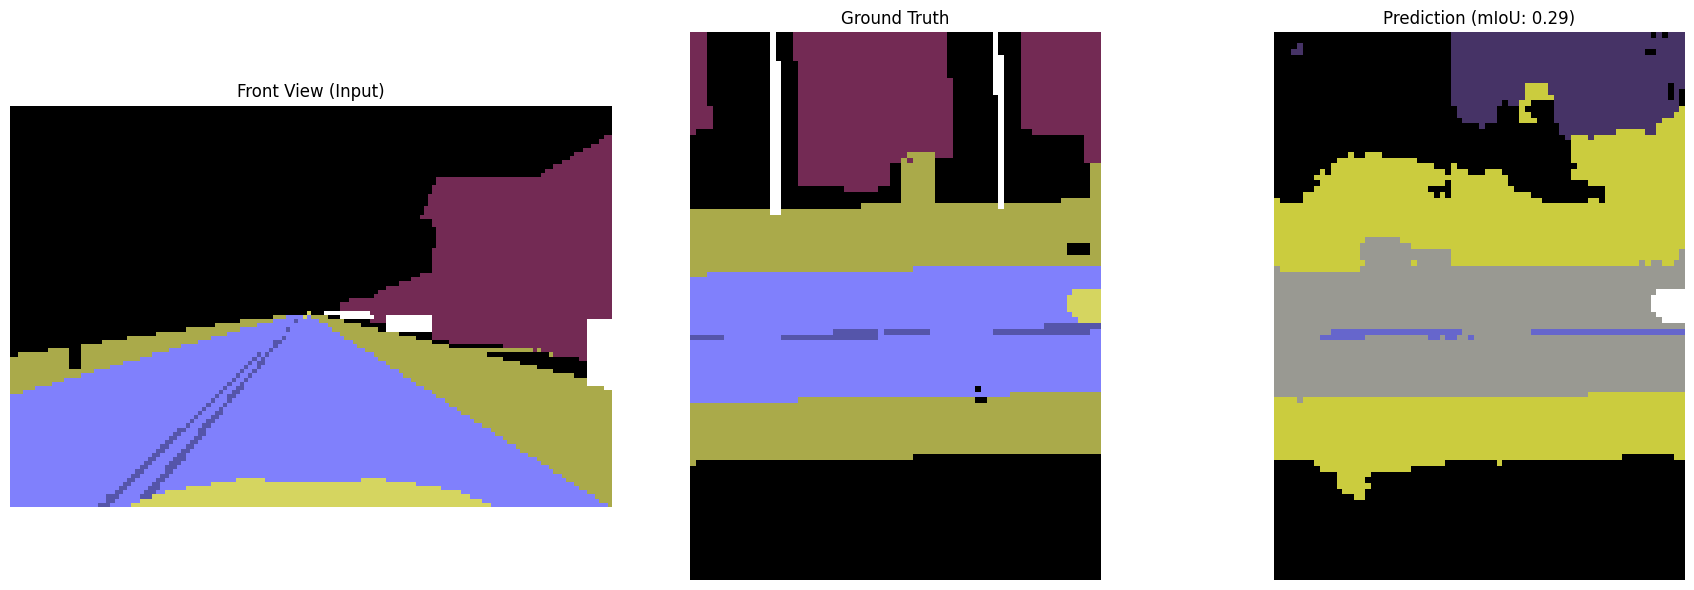

Batch 150:
Mean IoU (mIoU): 0.29
IoU per class:
  None: 0.63
  Buildings: 0.35
  Fences: 0.29
  Other: 0.89
  Pedestrians: 0.67
  Poles: 1.00
  RoadLines: 0.00
  Roads: 0.00
  Sidewalks: 0.00
  Vegetation: 0.00
  Vehicles: 0.00
  Walls: 0.00
  TrafficSigns: 0.00


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


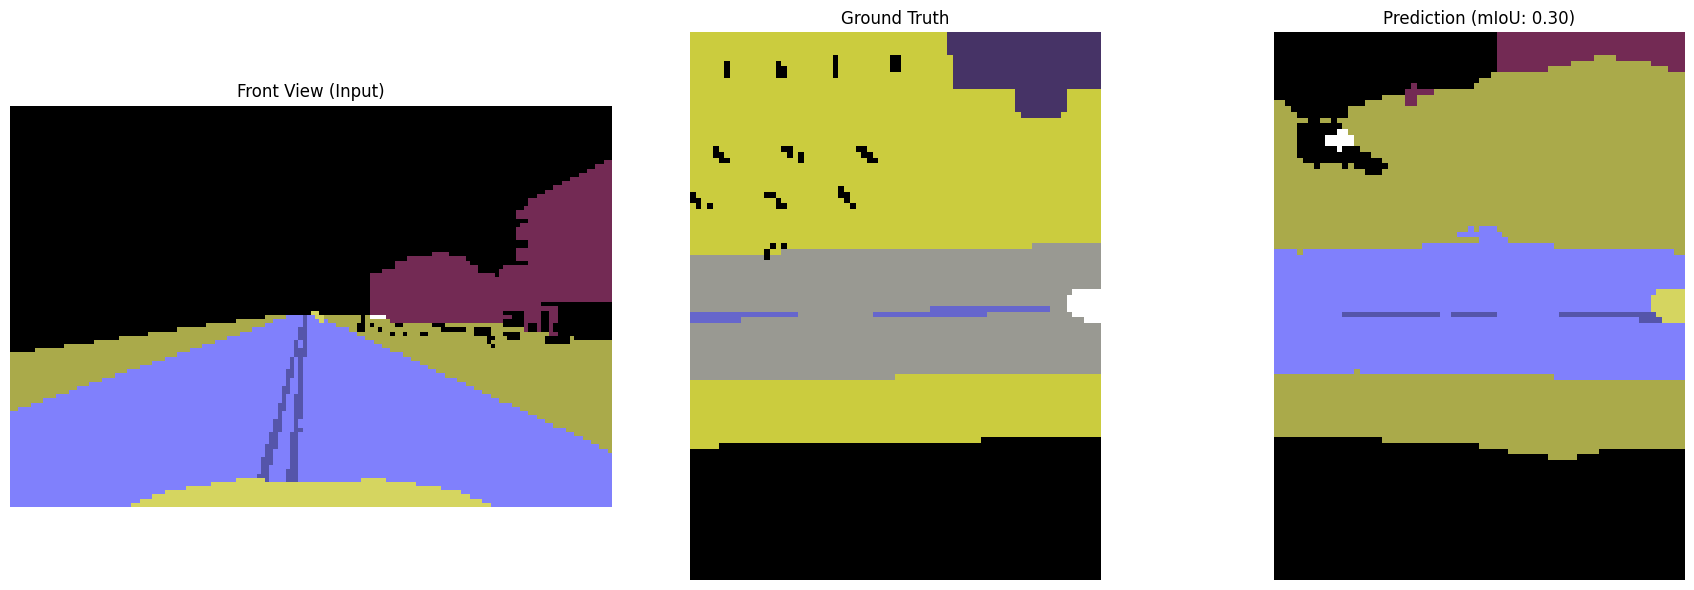

Batch 1909:
Mean IoU (mIoU): 0.30
IoU per class:
  None: 0.72
  Buildings: 0.41
  Fences: 0.16
  Other: 0.87
  Pedestrians: 0.72
  Poles: 0.97
  RoadLines: 0.00
  Roads: 0.00
  Sidewalks: 0.00
  Vegetation: 0.00
  Vehicles: 0.00
  Walls: 0.00
  TrafficSigns: 0.00


Average mIoU across 5 batches: 0.25


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import random

def compute_miou(prediction, ground_truth, num_classes):
    """
    Computes Mean Intersection over Union (mIoU) for a single prediction and ground truth pair.
    :param prediction: Predicted mask.
    :param ground_truth: Ground truth mask.
    :param num_classes: Number of classes.
    :return: mIoU and IoU per class.
    """
    iou_per_class = np.zeros(num_classes)
    for c in range(num_classes):
        intersection = np.sum((prediction == c) & (ground_truth == c))
        union = np.sum((prediction == c) | (ground_truth == c))
        if union > 0:
            iou_per_class[c] = intersection / union
    miou = np.nanmean(iou_per_class)
    return miou, iou_per_class

def plot_and_compute_miou_for_batches(model, generator, num_batches=5, num_classes=len(LABELS)):
    """
    Processes multiple random batches, visualizes each batch, and computes the average mIoU.
    :param model: Trained model for prediction.
    :param generator: Data generator providing input and ground truth.
    :param num_batches: Number of random batches to process.
    :param num_classes: Number of classes for mIoU calculation.
    """
    random_batches = random.sample(range(len(generator)), num_batches)  # Randomly select batch indices
    miou_values = []  # To store mIoU values for averaging

    for batch_index in random_batches:
        # Load the specific batch
        X, y = generator.__getitem__(batch_index)
        input_image = X[0]  # First (and only) image in the batch
        ground_truth = np.argmax(y[0], axis=-1)  # Convert one-hot encoded ground truth to class indices

        # Generate the model prediction
        predicted_mask = np.argmax(model.predict(np.array([input_image]))[0], axis=-1)

        # Compute mIoU
        miou, iou_per_class = compute_miou(predicted_mask, ground_truth, num_classes)
        miou_values.append(miou)

        # Create a figure to display the results
        fig, axes = plt.subplots(1, 3, figsize=(18, 6))

        # Convert input image to grayscale for better visualization
        input_image_gray = np.mean(input_image, axis=-1)

        # Input image
        axes[0].imshow(categorical_to_img(input_image), cmap='gist_stern', vmin=0, vmax=len(needed_labels) - 1)
        axes[0].set_title("Front View (Input)")
        axes[0].axis("off")

        # Ground truth
        axes[1].imshow(ground_truth, cmap="gist_stern")
        axes[1].set_title("Ground Truth")
        axes[1].axis("off")

        # Predicted result
        axes[2].imshow(predicted_mask, cmap="gist_stern")
        axes[2].set_title(f"Prediction (mIoU: {miou:.2f})")
        axes[2].axis("off")

        plt.tight_layout()
        plt.show()

        # Print detailed IoU per class with labels
        print(f"Batch {batch_index}:")
        print(f"Mean IoU (mIoU): {miou:.2f}")
        print("IoU per class:")
        for c, iou in enumerate(iou_per_class):
            class_name = LABELS.get(c, f"Class {c}")
            print(f"  {class_name}: {iou:.2f}")
        print("\n")

    # Calculate and display the average mIoU
    average_miou = np.mean(miou_values)
    print(f"Average mIoU across {num_batches} batches: {average_miou:.2f}")

# Example Usage
# Assuming `model` is your trained model and `val_generator` is the validation data generator
plot_and_compute_miou_for_batches(model, val_generator, num_batches=5, num_classes=len(LABELS))


In [ ]:
import numpy as np
import tensorflow as tf

# Define class labels
LABELS = {
    0: 'None',
    1: 'Buildings',
    2: 'Fences',
    3: 'Other',
    4: 'Pedestrians',
    5: 'Poles',
    6: 'RoadLines',
    7: 'Roads',
    8: 'Sidewalks',
    9: 'Vegetation',
    10: 'Vehicles',
    11: 'Walls',
    12: 'TrafficSigns',
}

def compute_iou(prediction, ground_truth, num_classes):
    """
    Computes IoU per class and mIoU for a single sample.
    :param prediction: Predicted mask.
    :param ground_truth: Ground truth mask.
    :param num_classes: Number of classes.
    :return: mIoU and IoU per class.
    """
    iou_per_class = np.zeros(num_classes)

    for c in range(num_classes):
        intersection = np.sum((prediction == c) & (ground_truth == c))
        union = np.sum((prediction == c) | (ground_truth == c))

        if union > 0:
            iou_per_class[c] = intersection / union  # Compute IoU for class c

    miou = np.nanmean(iou_per_class)  # Compute mean IoU ignoring NaN values
    return miou, iou_per_class

# Extract number of classes from LABELS
num_classes = len(LABELS)

# Initialize variables
total_iou = np.zeros(num_classes)  # Sum IoU values for averaging later
total_miou = []  # Store mIoU for each sample
num_samples = min(len(val_generator), 2000)  # Limit to 2000 samples

print("\nProcessing validation samples...")

# Iterate over validation dataset (limited to 2000 samples)
for i in range(num_samples):
    # Load input image and ground truth from val_generator
    X, y = val_generator.__getitem__(i)
    input_image = X[0]  # Extract image from batch
    ground_truth = np.argmax(y[0], axis=-1)  # Convert one-hot to class indices

    # Generate model prediction (Suppress print statements from TensorFlow)
    predicted_mask = np.argmax(model.predict(np.array([input_image]), verbose=0)[0], axis=-1)

    # Compute IoU and mIoU
    miou, iou_per_class = compute_iou(predicted_mask, ground_truth, num_classes)

    # Accumulate IoU values
    total_iou += np.nan_to_num(iou_per_class)  # Convert NaN to zero for summation
    total_miou.append(miou)  # Store mIoU

    # Print progress every 200 samples
    if (i + 1) % 200 == 0:
        print(f"✅ Processed {i + 1}/{num_samples} samples...")

# Compute final metrics
mean_iou_per_class = total_iou / num_samples  # Average IoU per class
mean_miou = np.nanmean(total_miou)  # Compute overall mean IoU

# Print results
print("\n🔹 **Mean IoU per Class:**")
for c, iou in enumerate(mean_iou_per_class):
    class_name = LABELS.get(c, f"Class {c}")
    print(f"  {class_name}: {iou:.4f}")

print(f"\n🔹 **Overall mIoU:** {mean_miou:.4f}")
print("\n✅ IoU evaluation completed!")




Processing validation samples...
✅ Processed 200/2000 samples...
✅ Processed 400/2000 samples...
✅ Processed 600/2000 samples...
✅ Processed 800/2000 samples...
✅ Processed 1000/2000 samples...
✅ Processed 1200/2000 samples...
✅ Processed 1400/2000 samples...
✅ Processed 1600/2000 samples...
✅ Processed 1800/2000 samples...
✅ Processed 2000/2000 samples...

🔹 **Mean IoU per Class:**
  None: 0.6369
  Buildings: 0.0817
  Fences: 0.1655
  Other: 0.7473
  Pedestrians: 0.5646
  Poles: 0.7016
  RoadLines: 0.0052
  Roads: 0.0000
  Sidewalks: 0.0000
  Vegetation: 0.0000
  Vehicles: 0.0000
  Walls: 0.0000
  TrafficSigns: 0.0000

🔹 **Overall mIoU:** 0.2233

✅ IoU evaluation completed!
